
# GA Facility Location — Toy Dataset Demo

This notebook demonstrates a **synthetic** facility-location problem suitable for a Genetic Algorithm (GA) tutorial.

## Install the environment 

**`pip install pygad numpy matplotlib`** 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
from GA_algorithm.data_loader import load_data
from GA_algorithm.config import config

data = load_data()

# Travel-time matrix (M x N) and incident frequency (length M)
T_full = data["time_matrix"]
incident_freq_full = data["incident_freq"]

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

N_full = T_full.shape[0]
assert T_full.shape[0] == T_full.shape[1], "T_full 必须是方阵"

# ======= 1) 选择 500 个格子 idx_500：热点优先 + 少量零格补齐 =======
# 若有 incident_freq_full，用它来评热点；否则用一个简单的“可达性分数”代替
if incident_freq_full is not None:
    freq = incident_freq_full.astype(float)
    # 热点 = 频次高；零格 = 频次==0
    pos_idx = np.where(freq > 0)[0]
    zero_idx = np.where(freq == 0)[0]
    # 先取 top 热点：例如前 400 个（可调）
    take_pos = min(400, len(pos_idx))
    pos_sorted = pos_idx[np.argsort(freq[pos_idx])[::-1]]
    pick_pos = pos_sorted[:take_pos]
    # 再补零格，保证稀疏性：例如补到 500
    need_zero = max(0, 500 - len(pick_pos))
    if need_zero > 0 and len(zero_idx) > 0:
        pick_zero = rng.choice(zero_idx, size=min(need_zero, len(zero_idx)), replace=False)
        idx_500 = np.unique(np.concatenate([pick_pos, pick_zero]))
    else:
        idx_500 = pick_pos
else:
    # 没有 incident_freq：用“1/(1+平均时间)”做一个粗评分，近似热点
    # 分数高的格子更像“中心/易达”，先取 400，再补 100 个随机
    score = 1.0 / (1.0 + np.mean(T_full, axis=1))
    top_pos = np.argsort(score)[-400:]           # 400 个“热点代理”
    others = np.setdiff1d(np.arange(N_full), top_pos, assume_unique=False)
    pick_zero_like = rng.choice(others, size=100, replace=False)
    idx_500 = np.sort(np.unique(np.concatenate([top_pos, pick_zero_like])))

assert len(idx_500) == 500, f"idx_500 长度应为 500，当前 {len(idx_500)}"

# ======= 2) 切 500×500 的时间子矩阵 =======
T_small = T_full[np.ix_(idx_500, idx_500)]  # (500, 500)
np.fill_diagonal(T_small, 0.0)

# ======= 3) 准备 500 维 incident_freq_small =======
if incident_freq_full is not None:
    incident_freq_small = incident_freq_full[idx_500].astype(int)
else:
    # Case B：没有真实 freq，则按“零膨胀 + 对数正态”合成一个类似分布
    # 可从全域近似估参数：用 T_full 的“中心性”作热点强度 lam
    score = 1.0 / (1.0 + np.mean(T_full, axis=1))          # (7597,)
    lam_full = (score - score.min()) / (score.max() - score.min() + 1e-12)
    lam_small = lam_full[idx_500]
    p0 = 0.85                          # 零比例（可调或由历史经验给定）
    mu, sig = np.log(3.0), 1.0         # 非零对数均值/方差（可调或由历史估参）
    rng2 = np.random.default_rng(43)
    is_zero = rng2.random(500) < p0
    val = np.zeros(500, dtype=int)
    nz = np.where(~is_zero)[0]
    base = np.exp(rng2.normal(mu, sig, size=len(nz)))
    scale = 0.5 + 1.5 * (lam_small[nz] / (lam_small.max() + 1e-12))
    val[nz] = np.round(base * scale).astype(int)
    cap = np.percentile(val, 99.5) if np.any(val > 0) else 0
    if cap > 0:
        val = np.clip(val, 0, cap).astype(int)
    incident_freq_small = val

# 基本信息
zeros_ratio = (incident_freq_small == 0).mean()
print(f"T_small shape: {T_small.shape}, zeros in freq: {zeros_ratio:.2%}")

# ======= 4) （可选）把候选列限制为 top10%（再并入公交） =======
USE_TOP10_CANDIDATES = False  # True 时启用
if USE_TOP10_CANDIDATES:
    w = incident_freq_small.astype(float)
    if w.sum() == 0:
        w = np.ones_like(w)
    w /= w.sum()
    site_score = (w[:, None] / (1.0 + T_small)).sum(axis=0)  # 每列的“覆盖分数”
    top_p = max(1, int(round(0.10 * T_small.shape[1])))
    cols_top = np.argsort(site_score)[-top_p:]
    if bus_mask_full is not None:
        # 把原 bus 并入再映射到 idx_500 的列坐标
        bus_cols_in_500 = np.nonzero(np.isin(idx_500, np.where(bus_mask_full)[0]))[0]
        cols_sel = np.union1d(cols_top, bus_cols_in_500)
    else:
        cols_sel = np.sort(cols_top)
    T_small = T_small[:, cols_sel]
    print(f"Restricted candidates to top10% (+bus): N_small={T_small.shape[1]}")

# ======= 5) 用肘部法给“需要多少消防站”的建议 =======
def greedy_k_curve(T, freq, Kmax=20, elbow_threshold_min=0.2):
    """
    简单贪心：每步加入一个站点（列），最小化加权平均时间。
    返回：(curve_k_wmean, suggested_k)
    """
    w = freq.astype(float)
    if w.sum() == 0:
        w = np.ones_like(w)
    w /= w.sum()

    M, N = T.shape
    best_dist = np.full(M, np.inf)
    chosen = []
    curve = []

    for step in range(1, min(Kmax, N)+1):
        gain_best, j_best = -np.inf, None
        for j in range(N):
            if j in chosen:
                continue
            cand = np.minimum(best_dist, T[:, j])
            gain = (w * (best_dist - cand)).sum()
            if gain > gain_best:
                gain_best, j_best = gain, j
        if j_best is None:
            break
        chosen.append(j_best)
        best_dist = np.minimum(best_dist, T[:, j_best])
        wmean = (w * best_dist).sum()
        curve.append((step, wmean))

    curve = np.array(curve)  # (steps, 2)
    # 肘部：边际改进 < 阈值 的第一个 k
    marginal = np.r_[np.nan, curve[:-1,1] - curve[1:,1]]
    k_star = int(curve[-1,0])
    for i in range(1, len(curve)):
        if marginal[i] < elbow_threshold_min:
            k_star = int(curve[i,0])
            break
    return curve, k_star

curve, k_star = greedy_k_curve(T_small, incident_freq_small, Kmax=20, elbow_threshold_min=0.2)
print("k vs weighted mean time (min):")
for k, wmean in curve:
    print(f"  k={int(k):2d} -> {wmean:.2f} min")
print(f"Suggested number of stations (elbow) k* = {k_star}")

## Generate synthetic data

In [ ]:
N = 40     # gene space
M = 200    # demand points
k = 6      # number of stations to select (each chromosome must contain k unique IDs)

# travel-time matrix (M x N), simulated 2~15 minutes
T = np.random.uniform(2, 15, size=(M, N)).astype(np.float32)
# demand weight (event frequency)
w = np.random.exponential(scale=1.0, size=M).astype(np.float32)

## What are `T (M×N)` and `w (M,)`?

- **`T`** is an `M×N` **travel-time matrix** in minutes.  
  `T[i, j]` means the travel time from **demand cell `i`** to **candidate site `j`**.

- **`w`** is an `M`-length **demand weight vector**.  
  `w[i]` quantifies the importance or frequency of demand at cell `i` (e.g., incident counts).

We will select **`k` stations** from the `N` candidates to minimize **weighted average travel time** and (optionally) maximize a **coverage** measure.


In [15]:
# data display
display(pd.DataFrame(T).head())
display(pd.DataFrame(w, columns=["w"]).head())


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,7.421286,11.364219,2.001487,5.930324,3.907827,3.200402,4.421383,6.492290,7.157977,9.004618,...,3.278509,7.474399,14.452564,8.931149,10.994403,6.101703,10.924512,12.850134,2.237748,11.751876
1,14.855194,11.726153,5.645772,12.260632,3.341938,7.822616,13.811742,5.816984,5.741079,3.690372,...,13.744225,3.787171,3.810592,12.496087,7.169799,4.149605,14.057611,6.520956,11.760557,11.437974
2,13.482979,10.107738,11.762252,6.535678,5.509063,13.646521,7.565186,14.542921,10.624740,10.082045,...,4.240427,3.782765,14.123741,11.058636,2.858002,11.821020,11.800390,13.999319,11.249822,3.615523
3,2.258442,2.340743,2.367984,5.200744,13.180364,9.004804,9.186686,12.946402,3.614253,5.629388,...,2.935666,14.574593,9.385306,4.642812,5.280235,11.669736,4.540583,9.557666,14.610260,13.008775
4,5.118021,8.419006,10.059424,12.776752,4.038288,2.241491,2.910288,8.322487,9.882283,9.395069,...,5.422858,2.857494,11.555858,12.038315,13.801606,14.115637,2.181370,5.046707,10.018119,14.337213


,w
0,0.453601
1,1.117029
2,0.805368
3,0.521575
4,0.507430


## Fitness Definition


We define **fitness** (to be maximized) as:

$$
\text{fitness}(\mathcal{S}) = -\overline{t}_w(\mathcal{S}) + \alpha \cdot \text{coverage}_\tau(\mathcal{S})
$$

- $\mathcal{S}$: the set of selected station indices (size `k`).  
- $\overline{t}_w$: weighted average of **minimum** travel time from each demand cell to the selected stations.  
- $\text{coverage}_\tau$: fraction of total demand $w$ covered within a threshold $\tau$ minutes.  
- $\alpha$: trade-off parameter.


In [16]:
tau = 6.0     # coverage threshold (minutes)
alpha = 1.0   # trade-off

def metrics(solution_ids):
    # solution_ids: array/list of unique station indices
    subT = T[:, solution_ids]          # (M, k)
    mins = subT.min(axis=1)            # (M,)
    avg_time = float((mins * w).sum() / w.sum())
    coverage = float(((mins <= tau) * w).sum() / w.sum())
    return avg_time, coverage

def fitness(solution_ids):
    avg_time, cov = metrics(solution_ids)
    return -avg_time + alpha * cov



## GA Setup (PyGAD)

We encode a solution as `k` integers (station IDs in `0..N-1`).  
We illustrate **initial population** and **mutation** effects.


In [17]:
# Ensure uniqueness of station IDs in a solution
def make_unique(solution):
    used = set()
    new = []
    pool = [i for i in range(N) if i not in solution]
    for g in solution:
        g = int(g)
        if g not in used:
            new.append(g); used.add(g)
        else:
            new_id = pool.pop() if pool else g
            new.append(new_id); used.add(new_id)
    return np.array(new, dtype=int)

# fitness function
def fitness_func(ga, sol, idx):
    sol = make_unique(sol.astype(int))
    return fitness(sol)

#### Construct initial populations: heuristic vs random vs mixed

- **Initial population** = the very first set of solutions (generation 0) given to GA;  
  Its shape is **(sol_per_pop, k)**:  
  - `sol_per_pop` = number of solutions (population size, rows).  
  - `k` = number of stations (genes per solution, columns).

- **heuristic**: start from a greedy solution (`greedy_seed(k)`), then randomly replace 1 site.  

- **random**: uniformly sample k distinct sites from all candidates.  



In [ ]:

def greedy_seed(k):
    remain = set(range(N))
    chosen = []
    mins = np.full(M, np.inf, dtype=np.float32)
    for _ in range(k):
        best_j, best_gain = None, -1e9
        for j in list(remain):
            cand = np.minimum(mins, T[:, j])
            avg_time = float((cand * w).sum() / w.sum())
            cov = float(((cand <= tau) * w).sum() / w.sum())
            gain = -avg_time + alpha * cov
            if gain > best_gain:
                best_gain = gain; best_j = j
        chosen.append(best_j)
        remain.remove(best_j)
        mins = np.minimum(mins, T[:, best_j])
    return np.array(chosen, dtype=int)

sol_per_pop = 30

# Random population
rand_pop = []
for _ in range(sol_per_pop):
    s = np.random.choice(N, size=k, replace=True)
    rand_pop.append(make_unique(s))
rand_pop = np.array(rand_pop, dtype=int)

# Heuristic population (greedy + light perturbation)
heuristic_pop = []
for _ in range(sol_per_pop):
    base = greedy_seed(k).copy()
    i = np.random.randint(0, k)
    cand_pool = [c for c in range(N) if c not in base]
    if cand_pool:
        base[i] = np.random.choice(cand_pool)
    heuristic_pop.append(make_unique(base))
heuristic_pop = np.array(heuristic_pop, dtype=int)


gene_space = [list(range(N)) for _ in range(k)]

def run_ga(initial_population, mutation_type, mutation_prob, replace, label):
    ga = pygad.GA(
        num_generations=100,
        num_parents_mating=8,
        fitness_func=fitness_func,
        initial_population=initial_population.copy(),
        parent_selection_type="tournament",
        K_tournament=3,
        crossover_type="uniform",
        mutation_type=mutation_type,            # "random" or "swap" etc.
        mutation_probability=mutation_prob,
        mutation_by_replacement=replace,        # only for "random" mutation
        gene_space=gene_space,
        allow_duplicate_genes=False,
        suppress_warnings=True,
    )
    ga.run()
    return label, ga


#### Run GA with a different initial population (Heuristic/random) and mutation (Swap/random)

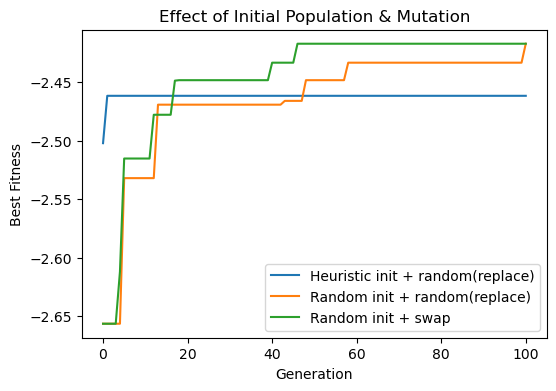

Heuristic init + random(replace)
  best fitness=-2.4616  sites=[13, 28, 31, 36, 5, 24]  avg_time=3.426  coverage=0.965

Random init + random(replace)
  best fitness=-2.4171  sites=[2, 0, 5, 14, 31, 36]  avg_time=3.381  coverage=0.964

Random init + swap
  best fitness=-2.4171  sites=[2, 36, 14, 5, 0, 31]  avg_time=3.381  coverage=0.964



In [20]:
runs = [
    run_ga(heuristic_pop, "random", 0.08, True,  "Heuristic init + random(replace)"),
    run_ga(rand_pop,      "random", 0.08, True,  "Random init + random(replace)"),
    run_ga(rand_pop,      "swap",   0.20, False, "Random init + swap"),
]

# Plot best fitness curves
plt.figure(figsize=(6,4))
for label, ga in runs:
    plt.plot(ga.best_solutions_fitness, label=label)
plt.xlabel("Generation"); plt.ylabel("Best Fitness"); plt.title("Effect of Initial Population & Mutation")
plt.legend()
plt.show()

# Inspect best solutions
for label, ga in runs:
    sol, fitv, idx = ga.best_solution(ga.last_generation_fitness)
    sol = make_unique(sol.astype(int))
    avg_time, cov = metrics(sol)
    print(f"{label}\n  best fitness={fitv:.4f}  sites={sol.tolist()}  avg_time={avg_time:.3f}  coverage={cov:.3f}\n")


#### Results: 	

	1.	Initial population effect
	•	The blue curve starts at a clearly higher fitness than the orange and green curves.
	This shows that the greedy heuristic provides a much stronger generation-0 solution.
	•	Random initial populations (orange, green) start lower, but bring higher diversity.
	
	2.	Convergence process
	•	The orange (Random + random replace) and green (Random + swap) runs, although weaker at the start, quickly improve within the first 10–20 generations and reach the same level as the heuristic run after ~30 generations.
	•	The heuristic run improves slightly in the first few generations but then stagnates, showing a tendency for premature convergence.
	•	Overall, heuristic seeds give a faster start, while random seeds allow stronger exploration and catch up later.